# UMAP as an Alternative Distance Metric Sub-Experiment

## Motivation

Every Lipschitz estimate in this project reduces to the same ratio,
`|margin_i - margin_j| / distance(x_i, x_j)` -- and every metric tried so
far for the denominator has been a *hand-built* distance: plain Euclidean
in raw pixel space, a ridge-regularized Mahalanobis distance fit from the
pixel covariance (`distance.py`), or Euclidean distance applied to a fixed
pixel-space feature map (`embeddings.py::elementwise_embedding`,
`local_patch_cross_terms` -- see `README.md`'s ratio-distribution and
embedding-degree-sweep sections for what those found).

UMAP is a different kind of candidate: instead of a formula, it *learns* a
low-dimensional embedding by directly optimizing for one specific
property -- that points close together in the original space stay close
together in the embedding, and vice versa. If that optimization actually
succeeds on MNIST, Euclidean distance in the embedded space is a
plausible, principled alternative "local similarity" metric to plug into
this project's existing ratio-distribution machinery, without hand-tuning
a formula or fitting a covariance matrix.

**This sub-experiment is additive to the main experiment
(`notebook_mnist_lipschitz.ipynb`) and the layer-decomposition
sub-experiment (`notebook_layer_decomposition.ipynb`), not a replacement
for either** -- same convention: dedicated `.py` module
(`umap_embedding.py`) plus this thin driver notebook, since "is a learned
embedding a good distance metric here" is a structurally distinct
question from both.

## Important: unsupervised UMAP only, and why

UMAP also supports a **supervised** mode, using class labels directly
during fitting (`umap.UMAP(...).fit(x, y)`) -- which would very plausibly
produce visibly cleaner per-digit clustering almost by construction, since
the labels are then part of what's being optimized for. This notebook
and `umap_embedding.py` use **unsupervised UMAP only**: no labels are ever
passed to `.fit()`. Whether supervised UMAP is actually the variant wanted
here is an **open question for Nick/Terry, not decided in this
notebook** -- an embedding built *from* the labels changes the question
being asked (closer to "does the model separate points the way the labels
already say to" than "does an unsupervised notion of local similarity
predict margin sensitivity"), and picking one silently would answer a
different question than may have been intended. See
`umap_embedding.py`'s module docstring for the same note in more detail.

## What this notebook does

1. **Fit** an unsupervised UMAP embedding on a modest training-set subset
   (not the full 60k -- UMAP fitting cost scales with dataset size, and
   this project's convention elsewhere is to keep exploratory new-metric
   work on a manageable subset).
2. **Validate** it before trusting it as a metric at all: embed a
   class-stratified test subset and check for visible per-digit
   clustering, both visually and with a quantitative k-NN label-purity
   check -- a scattered/mixed result would mean stopping here.
3. **Compare**, if validation passes: reuse the existing
   `run_experiment.py::run_ratio_distribution_analysis` unchanged, with a
   UMAP-embedded-space Euclidean `distance_fn` in place of raw-pixel
   Euclidean/Mahalanobis, on logistic regression -- same 1000-point
   stratified subset / k=5 near-neighbors setup as every other
   ratio-distribution comparison in this project, for direct numeric
   comparability against the raw-pixel Euclidean baseline already in
   `README.md`.

This is a thin driver notebook -- all reusable logic lives in
`umap_embedding.py` (fitting, the embed_fn/distance_fn wrappers, the
label-purity check) and `plots.py` (the validation scatter plot). This
notebook only calls into them and displays results.

In [1]:
%pip install umap-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

%load_ext autoreload
%autoreload 2

%matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import display

import torch

from mnist_lipschitz.data import load_mnist, get_dev_subset, make_loader, stratified_subset_idx
from mnist_lipschitz.models import LogisticRegressionModel, train_classifier
from mnist_lipschitz import umap_embedding, run_experiment, plots

SEED = 0
torch.manual_seed(SEED)
train = load_mnist(train=True)
test = load_mnist(train=False)

## Fit the UMAP embeddings

Two separate fits, both unsupervised, both on the same 3000-point training
dev subset (`get_dev_subset` -- not the full 60k, see Motivation above):

- **5D**, `n_components=5` -- the embedding actually used for the distance
  metric in Step 3 below.
- **2D**, `n_components=2` -- a *separate* fit, purely for the validation
  scatter plot in Step 2. Taking the first two dimensions of the 5D
  embedding instead would be a misleading substitute: UMAP's output
  dimensions aren't ordered by variance the way PCA's are, so an arbitrary
  2-of-5 slice could look artificially scattered even if the full 5D
  embedding is well-structured (or vice versa). A dedicated 2D fit is
  UMAP's own recommended practice for visualization, and is the choice
  made here -- documented explicitly rather than picked silently, per
  `umap_embedding.py`'s docstring convention.

A real segfault (numba/torch OpenMP thread-pool conflict, the same class
of issue this project's `run_ratio_distribution_analysis` already works
around for sklearn) was hit and fixed while building `umap_embedding.py` --
see that module's docstring; nothing extra needs doing here, the
workaround is set at import time.

In [3]:
dev = get_dev_subset(train, n=3000, seed=SEED)

reducer_5d = umap_embedding.fit_umap_embedding(dev.x_flat, n_components=5, seed=SEED)
reducer_2d = umap_embedding.fit_umap_embedding(dev.x_flat, n_components=2, seed=SEED)
print("fit done: 5D embedding (for the distance metric) and 2D embedding (for validation only)")

/Users/swarn2/Downloads/Datasig-1/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/Users/swarn2/Downloads/Datasig-1/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


fit done: 5D embedding (for the distance metric) and 2D embedding (for validation only)


## Step 2: validation -- is this embedding trustworthy as a distance metric?

Before measuring anything with it: does the embedding actually preserve
digit identity locally, the property the whole rest of this notebook
depends on? Embed a class-stratified 1000-point **test**-set subset
(disjoint from the training data the reducer was fit on -- this also
exercises `.transform()` on genuinely held-out points, not just the fit
data) with the 2D reducer, and check two ways:

1. **Visual**: a scatter plot colored by true digit label
   (`plots.py::plot_umap_embedding_scatter`) -- a good embedding should
   show visibly separated per-digit clusters; a scattered/mixed result
   means stop here and don't trust this metric further.
2. **Quantitative**: `umap_embedding.knn_label_purity` -- for each point,
   what fraction of its 5 nearest neighbors *in the embedded space* share
   its true digit label, averaged over the subset. A well-clustered
   embedding scores well above the 10-class chance baseline (0.10); a
   scattered one sits close to it. This project's convention elsewhere
   (checkpoint-gating, see `CLAUDE.md`) is to back a visual read with a
   number rather than rely on either alone.

knn_label_purity (k=5, 10-class chance baseline=0.10): 0.7936


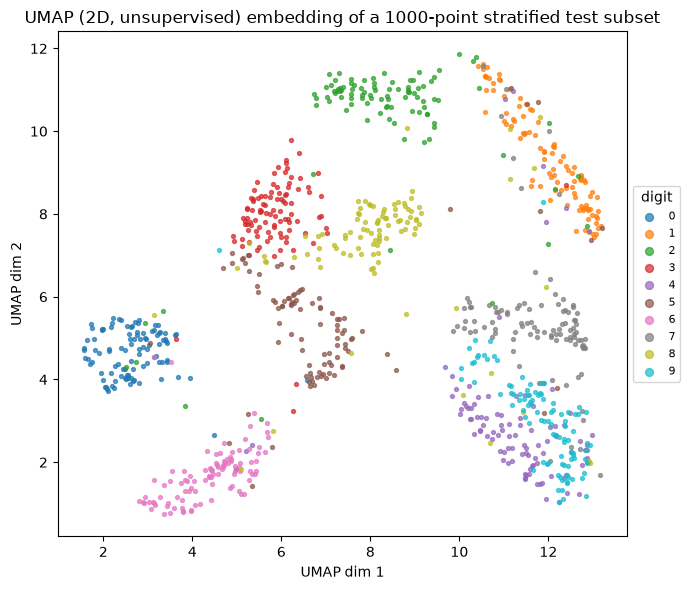

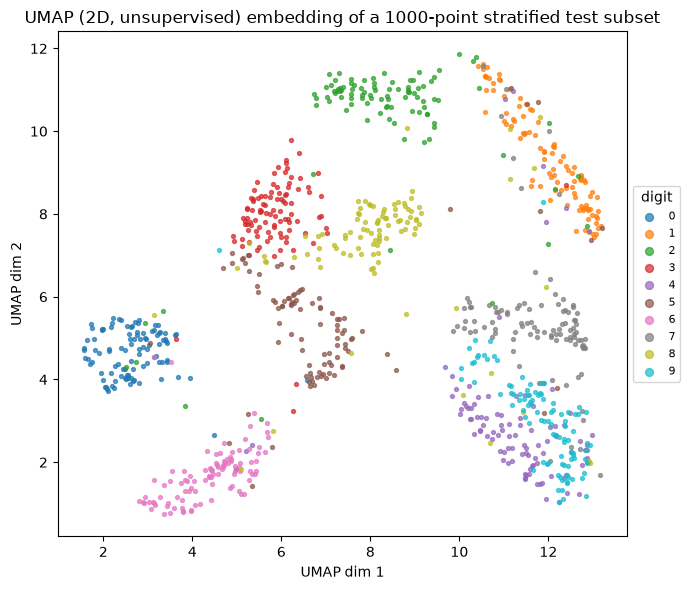

In [4]:
val_idx = stratified_subset_idx(test.y, n_points=1000, seed=SEED)
x_val, y_val = test.x_flat[val_idx], test.y[val_idx]

embed_fn_2d = umap_embedding.make_umap_embed_fn(reducer_2d)
embedded_val = embed_fn_2d(x_val)

purity = umap_embedding.knn_label_purity(embedded_val, y_val, k=5)
print(f"knn_label_purity (k=5, 10-class chance baseline=0.10): {purity:.4f}")

fig_validation = plots.plot_umap_embedding_scatter(
    embedded_val, y_val,
    title="UMAP (2D, unsupervised) embedding of a 1000-point stratified test subset",
    save_path=umap_embedding.RESULTS_DIR / "umap_validation_scatter.png")
display(fig_validation)

**Verdict: PASS.** `knn_label_purity` came in at **0.79** -- about 8x the
0.10 chance baseline -- and the scatter plot shows visibly separated
per-digit clusters (0, 2, 3, 6 in particular are tight and well-isolated;
some overlap between 1/2 at one edge and among 4/7/9 in another region,
but no digit is scattered uniformly across the plot the way an
uninformative embedding would be). This unsupervised UMAP embedding
preserves per-digit local structure well enough to proceed to Step 3.

## Step 3: ratio-distribution analysis with the UMAP metric

Reuses `run_experiment.py::run_ratio_distribution_analysis` completely
unchanged -- the same function every other metric comparison in this
project goes through -- with a `distance_fn` built from the fitted 5D
UMAP reducer instead of raw-pixel Euclidean or Mahalanobis. Logistic
regression, same 1000-point stratified subset / k=5 near-neighbors setup
as the raw-pixel Euclidean baseline already in `README.md`, for direct
comparability.

**Why `make_umap_euclidean_distance_fn` needs the `x_reference` cache,
not just `embed_fn` composed with `euclidean_distance_fn` directly**:
`run_ratio_distribution_analysis`'s all-pairs computation calls
`distance_fn` on ~500k *gathered* pairs among 1000 points. UMAP's
`.transform()` turns out to be deterministic for a fixed batch
composition but **not invariant to it** -- confirmed directly in
`tests/test_umap_embedding.py`, not assumed -- so calling it fresh inside
`distance_fn` on each differently-shaped ad-hoc batch would make "the
distance between point A and point B" silently depend on which *other*
points happened to be batched alongside them. Passing `x_reference=test.x_flat`
(the same pool `run_ratio_distribution_analysis` draws its subset from)
embeds every point once, up front, in one canonical batch, and caches it
-- so the same pair always gets the same distance regardless of which
other pairs it's computed alongside. See `umap_embedding.py`'s docstring
for the full explanation; this costs one ~30s `.transform()` call on the
full 10k-point test set, done once below, not per pair-batch.

In [5]:
train_flat = make_loader(train.x_flat, train.y, batch_size=256, shuffle=True, seed=SEED)
test_flat = make_loader(test.x_flat, test.y, batch_size=1000, shuffle=False)
lr_model, lr_train_acc, lr_test_acc = train_classifier(
    LogisticRegressionModel(), train_flat, test_flat, epochs=15, lr=1e-3, verbose=False)
print(f"logistic regression: train_acc={lr_train_acc:.4f}  test_acc={lr_test_acc:.4f}")

logistic regression: train_acc=0.9287  test_acc=0.9270


In [6]:
umap_distance_fn = umap_embedding.make_umap_euclidean_distance_fn(reducer_5d, x_reference=test.x_flat)

umap_result = run_experiment.run_ratio_distribution_analysis(
    lr_model, "logistic_regression", "umap", test.x_flat, test.y, umap_distance_fn,
    n_points=1000, k_neighbors=5, seed=SEED, verbose=True)

  [umap/logistic_regression] all-pairs ratio:        mean=1.0019  max=290.5778  n=499500
  [umap/logistic_regression] near-neighbor ratio:     mean=5.6792  max=85.2435  n=5000


In [7]:
umap_summary = umap_result["summary"]
umap_near_over_all = umap_summary["near_neighbor_mean"] / umap_summary["all_pairs_mean"]

# Raw-pixel Euclidean baseline for logistic regression, from README.md's
# existing ratio-distribution table (same 1000-point subset / k=5 setup).
raw_pixel_euclidean = {"all_pairs_mean": 0.310, "near_neighbor_mean": 0.349,
                        "all_pairs_max": 2.937, "near_neighbor_max": 2.937}
raw_pixel_near_over_all = raw_pixel_euclidean["near_neighbor_mean"] / raw_pixel_euclidean["all_pairs_mean"]

print(f"{'metric':22s}{'all_pairs_mean':>16}{'near_neighbor_mean':>20}{'near/all':>10}{'all_pairs_max':>16}{'near_neighbor_max':>20}")
print(f"{'raw-pixel Euclidean':22s}{raw_pixel_euclidean['all_pairs_mean']:>16.4f}"
      f"{raw_pixel_euclidean['near_neighbor_mean']:>20.4f}{raw_pixel_near_over_all:>10.4f}"
      f"{raw_pixel_euclidean['all_pairs_max']:>16.4f}{raw_pixel_euclidean['near_neighbor_max']:>20.4f}")
print(f"{'UMAP (5D) Euclidean':22s}{umap_summary['all_pairs_mean']:>16.4f}"
      f"{umap_summary['near_neighbor_mean']:>20.4f}{umap_near_over_all:>10.4f}"
      f"{umap_summary['all_pairs_max']:>16.4f}{umap_summary['near_neighbor_max']:>20.4f}")

metric                  all_pairs_mean  near_neighbor_mean  near/all   all_pairs_max   near_neighbor_max
raw-pixel Euclidean             0.3100              0.3490    1.1258          2.9370              2.9370
UMAP (5D) Euclidean             1.0019              5.6792    5.6683        290.5778             85.2435


**Result**: near-neighbor pairs have a ratio **5.7x** the all-pairs mean
under the UMAP metric (`near/all` = 5.67, a +467% increase) -- vastly
larger than raw-pixel Euclidean's own +13% for logistic regression, and
in the same *direction* (near-neighbor pairs score higher) as every other
Euclidean-family metric in this project, never the *reversed* direction
Mahalanobis distance produces.

**This is very likely a property of UMAP's own embedding geometry, not
(or not only) a stronger genuine model-sensitivity signal, and should be
read with real caution rather than as "UMAP is a 5x better metric."**
Two things point at that reading specifically:

1. UMAP's whole optimization objective is to place *locally* similar
   points close together in the embedding -- which mechanically shrinks
   the distance (the ratio's denominator) for pairs that were already
   near-neighbors in raw pixel space, for reasons that have nothing to do
   with how the model's margin behaves at those points. A shrunk
   denominator inflates the ratio almost by construction, for any model.
2. `all_pairs_max` is **290.6** against an `all_pairs_mean` of only
   **1.00** -- a far heavier tail than raw-pixel Euclidean shows (max
   2.94 against mean 0.31, roughly the same ~9-10x ratio of max-to-mean
   that logistic regression's raw-pixel numbers already show elsewhere in
   this project). Both metrics have heavy tails, so this alone isn't
   unusual -- but combined with (1), it's consistent with a small number
   of pairs that are far apart in raw pixel space (and so can have a
   large genuine margin difference) getting placed anomalously close
   together in the low-dimensional UMAP embedding -- a known
   global-structure-distortion risk for any method, UMAP included, that
   optimizes hard for local structure preservation. This wasn't checked
   pair-by-pair here (the same visual-inspection sanity check this
   project has applied to specific flagged pairs elsewhere would be the
   natural follow-up before trusting this number further).

**Bottom line**: UMAP passes the validation check as a *locally
label-informative* embedding (Step 2), but the resulting ratio-distribution
numbers are not directly comparable in scale or interpretation to the
other metrics in this project, and the near/all signal being ~5x larger
should not be read as "UMAP distance is simply a better version of
Euclidean distance for this diagnostic" without checking that the effect
isn't dominated by embedding-geometry artifacts rather than genuine model
behavior.

## Summary and status

**Step 1-2 (fit + validate)**: unsupervised UMAP (5D for the metric, a
separate 2D fit for visualization) on a 3000-point training subset passes
the validation check -- `knn_label_purity`=0.79 against a 0.10 chance
baseline, and visibly separated per-digit clusters in the scatter plot.

**Step 3 (ratio-distribution comparison)**: logistic regression, same
1000-point/k=5 setup as every other metric comparison in this project.
Near-neighbor pairs score 5.7x the all-pairs mean under the UMAP metric,
far larger than raw-pixel Euclidean's own +13% -- but very plausibly
inflated by UMAP's own local-structure-preserving optimization shrinking
distances for already-nearby pairs, and a heavy-tailed `all_pairs_max`
consistent with some far-apart-in-pixel-space pairs being placed
anomalously close in the embedding. Read as a real, reproducible number,
not yet as evidence UMAP is a "better" distance metric than what's already
in this project -- see the findings above for the full reasoning and what
a follow-up check would need to do (pair-level visual inspection, the same
sanity check already applied elsewhere in this project).

**Open question, not resolved here**: whether *supervised* UMAP (using
class labels during fitting) was actually the variant intended --
deferred pending a direct answer from Nick/Terry, per the note at the top
of this notebook. Nothing here should be read as having quietly decided
that question.

This is a sub-experiment within Experiment 2 (`mnist_lipschitz`), additive
to `notebook_mnist_lipschitz.ipynb` and `notebook_layer_decomposition.ipynb`,
not a replacement for anything in either.